# CPWL time to accuracy, with an optional exact-SVD reference line
Time to accuracy (exp5), re-run on the CPWL spectral operator of exp6 (the $\mathrm{clip}$ profile by default): wall-clock time of the decomposition-free CPWL operator, evaluated through `sign_map.make_sgn_ns_until`, until every internal $\mathrm{Sgn}$ call reaches a target $\varepsilon$, as a function of the degree $D$. With `svd_reference_line=True`, the exact SVD-based evaluation time of the same CPWL operator is also timed and drawn as a horizontal dashed line. Each of the `n_reps` repetitions uses a new random matrix of the same size and $\sigma_{\min}$, so the reported std is over matrices. Edit the config and rerun; set `devices=["cpu"]` without a GPU, and keep $\varepsilon$ above the rounding level of the dtype (about $10^{-6}$ in float32).

In [1]:
import sys
sys.path.insert(0, "..")  # repo root, so ns_core and experiments import

import matplotlib.pyplot as plt
import torch

from ns_core import plots
from experiments.cpwl_time_to_accuracy import CPWLTimeToAccuracyConfig, run_cpwl_time_to_accuracy
%matplotlib inline

In [2]:
cfg = CPWLTimeToAccuracyConfig(
    sizes=[256], smins=[1e-2], degrees=[1, 2, 3, 4, 5, 6],
    devices=["cpu"], dtypes=[torch.float64], eps=[1e-8],
    k_max=50, svd_reference_line=True,
    power_iters=10, power_margin=1.1, n_warmup=2, n_reps=5, cpu_threads=None, seed=0,
)
res = run_cpwl_time_to_accuracy(cfg)

n=256 smin=0.01: 5 matrices


  cpu, float64, eps=1e-08: D=1 40.01 ms (K=17) | D=2 36.02 ms (K=11) | D=3 37.03 ms (K=9) | D=4 37.02 ms (K=8) | D=5 46.80 ms (K=7) | D=6 49.34 ms (K=7)


## Time to reach $\varepsilon$ against the degree $D$, with the SVD line

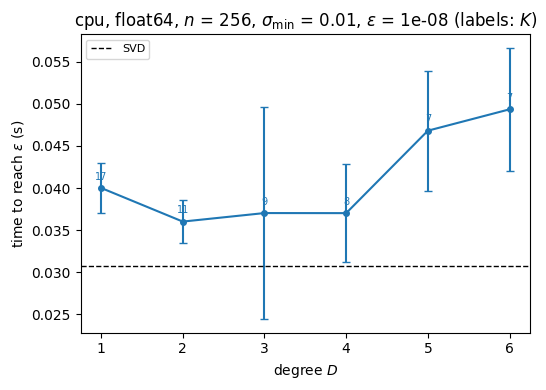

In [3]:
sel = dict(device="cpu", dtype=torch.float64, n=cfg.sizes[0], smin=cfg.smins[0], eps=cfg.eps[0])
ax = plots.plot_time_vs_degree(res, **sel)
if cfg.svd_reference_line:
    plots.add_svd_reference_line(ax, res, sel["device"], sel["dtype"], sel["n"], sel["smin"])
ax.figure.tight_layout()

## Precisions (or devices, sizes, ...) compared on one axis, SVD line per curve

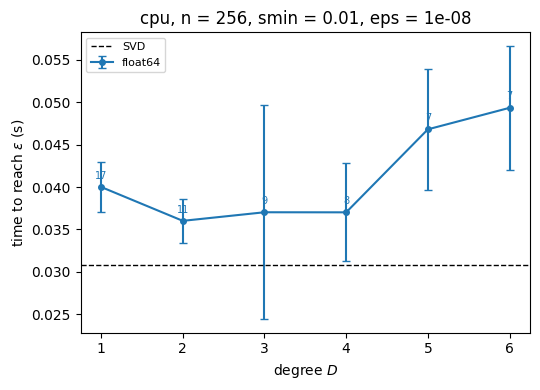

In [4]:
fig, ax = plt.subplots(figsize=(5.5, 4))
for dtype in cfg.dtypes:
    plots.plot_time_vs_degree(
        res, "cpu", dtype, cfg.sizes[0], cfg.smins[0], cfg.eps[0],
        ax=ax, label=str(dtype).removeprefix("torch."),
    )
if cfg.svd_reference_line:
    plots.add_svd_reference_line(ax, res, "cpu", cfg.dtypes[0], cfg.sizes[0], cfg.smins[0])
ax.set_title(f"cpu, n = {cfg.sizes[0]}, smin = {cfg.smins[0]:g}, eps = {cfg.eps[0]:g}")
fig.tight_layout()